# Quantitative Structure–Property Relationships for Liquid Crystals

Companion code for:

> **Machine Learning Analysis for the Contribution of Molecular Fine
> Structures to the Symmetry of Liquid Crystals** —
> Yoshiaki Uchida, Shizuo Kaji, Naoto Nakano.

This notebook provides two families of models that predict liquid-crystal
phase sequences and transition temperatures directly from SMILES:

1. **Gradient Boosting (CatBoost / LightGBM)** operating on Mordred
   molecular descriptors.
2. **Graph Neural Networks (PyG / GATv2Conv / NNConv)** operating on the
   molecular graph.

A typical workflow is:

- **Inference** — load the bundled pre-trained models and predict phases
  for new SMILES (most users only need this section).
- **Training** — re-train the models on your own descriptor database.
- **Dataset preparation** — parse a LiqCryst-style `Phases` column and
  compute Mordred descriptors for a CSV of SMILES.


## 1. Environment setup

Run this cell **once** to install the required libraries into the current
kernel.  CUDA is optional; when unavailable the notebook transparently
falls back to CPU.


In [ ]:
# Base scientific / cheminformatics stack
# %pip install --quiet numpy pandas matplotlib seaborn tqdm pyarrow joblib scipy scikit-learn
# %pip install --quiet rdkit mordred iterative-stratification

# Gradient boosting
# %pip install --quiet catboost lightgbm shap

# (Optional) hyper-parameter tuning
# %pip install --quiet optuna statannotations

# PyTorch + PyTorch Geometric (choose the wheel that matches your CUDA/CPU setup)
# See https://pytorch.org and https://pytorch-geometric.readthedocs.io
# %pip install --quiet torch torcheval
# %pip install --quiet torch_geometric


## 2. Imports and helpers

All subsequent cells assume that this block has been executed.


In [1]:
import os
import re
import time
import warnings
from collections import Counter, OrderedDict
from datetime import datetime
from typing import Optional

import joblib
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import Draw
from mordred import Calculator, descriptors

from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, precision_score, roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import catboost
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from catboost.utils import get_gpu_device_count

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.display.max_columns = 100

print(f"CatBoost  : {catboost.__version__}")


CatBoost  : 1.2.7


In [2]:
# ---------------------------------------------------------------------
# Cross-validation splitting helper
# ---------------------------------------------------------------------
def cv_split(mode, sub_df, n_splits=5, targets=None, random_state=42):
    """Return train/test index lists for stratified K-fold CV."""
    if mode == "classification":
        if len(targets) == 1:
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        else:
            skf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    else:
        skf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_indices, test_indices = [], []
    for train_i, test_i in skf.split(sub_df, sub_df.loc[:, targets]):
        train_indices.append(train_i)
        test_indices.append(test_i)
    return train_indices, test_indices


# ---------------------------------------------------------------------
# Result summariser
# ---------------------------------------------------------------------
def print_results(result_df, targets, use_desc=None, display="all", truth="true_"):
    print(f"Number of SMILES: {len(result_df)}")
    if use_desc is not None:
        print(f"{use_desc}: num of variables: {len(varnames)}")

    rows = []
    for target in targets:
        num_classes = result_df[truth + target].nunique()
        if num_classes < 2:
            continue
        print(f"\nPrediction target {target} ({num_classes} classes)")
        if display == "all":
            print(classification_report(result_df[truth + target], result_df["pred_" + target], digits=5))
            print(confusion_matrix(result_df[truth + target], result_df["pred_" + target]))
        else:
            print("Accuracy:       ", round(metrics.accuracy_score(result_df[truth + target], result_df["pred_" + target]), 5))
        print("Cohen's kappa:  ", metrics.cohen_kappa_score(result_df[truth + target], result_df["pred_" + target]))
        print("Matthew's coef: ", metrics.matthews_corrcoef(result_df[truth + target], result_df["pred_" + target]))

        row = {"type": target.replace("type", "")}
        row["npos"] = int((result_df[truth + target] > 0).sum())
        row["N"] = len(result_df)
        row["acc"]       = round(metrics.accuracy_score(result_df[truth + target] > 0, result_df["pred_" + target] > 0), 5)
        row["recall"]    = round(metrics.recall_score(result_df[truth + target] > 0, result_df["pred_" + target] > 0), 5)
        row["precision"] = round(metrics.precision_score(result_df[truth + target] > 0, result_df["pred_" + target] > 0), 5)
        row["f1"]        = round(metrics.f1_score(result_df[truth + target] > 0, result_df["pred_" + target] > 0), 5)
        print(f"Positives:      {row['npos']} / {row['N']}")

        if f"pos_conf_{target}" in result_df:
            auc = roc_auc_score(result_df[truth + target] > 0, result_df["pos_conf_" + target])
            row["AUC"] = auc
            print(f"AUC:            {auc:.5f}")

        # temperature accuracy for this phase (if present)
        lte = f"error_{target[0]}"
        if lte + "p" in result_df:
            row["Tp_mean"] = result_df[lte + "p"].mean()
            row["Tp_std"]  = result_df[lte + "p"].std()
            row["Tm_mean"] = result_df[lte + "m"].mean()
            row["Tm_std"]  = result_df[lte + "m"].std()

        if num_classes > 2 and display != "all":
            print("Cohen's kappa (2-class): ", metrics.cohen_kappa_score(result_df[truth + target] > 0, result_df["pred_" + target] > 0))
            print("Matthew's coef (2-class):", metrics.matthews_corrcoef(result_df[truth + target] > 0, result_df["pred_" + target] > 0))
        rows.append(row)
    return pd.DataFrame(rows).set_index("type")


# ---------------------------------------------------------------------
# Reconstruct a LiqCryst-style Phase sequence from prediction columns
# ---------------------------------------------------------------------
def pred_phases(results_df):
    seqs = []
    for _, sd in tqdm(results_df.iterrows(), total=len(results_df)):
        ph = f"Cr {sd['pred_Melting']:.2f}"
        items = []
        for t in phase_types:
            if sd[f"pred_{t}type"] > 0:
                label = "Dh" if t == "D" else t
                label = label if sd[f"pred_{t}type"] == 1 else label + "*"
                items.append((sd[f"pred_{t}m"], label, sd[f"pred_{t}p"]))
            elif t + "*type" in phase_targets and sd[f"pred_{t}*type"] > 0:
                items.append((sd[f"pred_{t}m"], t + "*", sd[f"pred_{t}p"]))
        for item in sorted(items, key=lambda x: x[2]):
            ph += f" {item[0]:.2f} {item[1]} {item[2]:.2f}"
        ph += f" {sd['pred_Clearing']:.2f} is"
        seqs.append(ph)
    return seqs


# ---------------------------------------------------------------------
# Joblib + tqdm integration (for parallel descriptor calculation)
# ---------------------------------------------------------------------
class ProgressParallel(joblib.Parallel):
    def __init__(self, use_tqdm=True, total=None, *args, **kwargs):
        self._use_tqdm = use_tqdm
        self._total = total
        super().__init__(*args, **kwargs)

    def __call__(self, *args, **kwargs):
        with tqdm(disable=not self._use_tqdm, total=self._total) as self._pbar:
            return super().__call__(*args, **kwargs)

    def print_progress(self):
        if self._total is None:
            self._pbar.total = self.n_dispatched_tasks
        self._pbar.n = self.n_completed_tasks
        self._pbar.refresh()


## 3. Global settings

Tune these values to match your hardware and experiment.  They are used by
every subsequent section.


In [3]:
# --- Compute ---------------------------------------------------------
num_cores    = min(multiprocessing.cpu_count() - 1, 32)
random_state = 42            # global random seed used for CV splitting
outdir       = "result_test"  # output directory
os.makedirs(outdir, exist_ok=True)

# --- Physical / chemical constants ----------------------------------
kelv = -273.15
permitted_list_of_atoms = [
    "H", "C", "N", "O", "S", "F", "Si", "P", "Cl", "Br", "Mg", "Na", "Ca",
    "Fe", "As", "Al", "I", "B", "V", "K", "Tl", "Yb", "Sb", "Sn", "Ag",
    "Pd", "Co", "Se", "Ti", "Zn", "Li", "Ge", "Cu", "Au", "Ni", "Cd", "In",
    "Mn", "Zr", "Cr", "Pt", "Hg", "Pb", "Unknown",
]

# --- Phase vocabulary ------------------------------------------------
phase_types          = ["N", "A", "B", "C", "E", "F", "G", "H", "I", "J", "Dh", "BP"]
phase_types_chiral   = phase_types + ["N*", "C*", "E*", "F*", "I*"]
separate_asterisk_phases = True     # treat chiral phases (e.g. N*) as a separate target
phase_targets        = [f"{p}type" for p in phase_types_chiral]

# --- Temperature targets --------------------------------------------
temperature_types = ["Clearing", "Melting"]
for lt in phase_types:
    temperature_types.extend([lt + "p", lt + "m"])
temp_targets = temperature_types

# --- Columns that must NOT be used as explanatory variables ---------
nonvars = [
    "ID", "SMILES", "Phases", "rac_en", "Melting", "Meltingtype",
    "Clearingtype", "Clearing",
    "Stype", "Xtype", "Ytype",         # ambiguous phases
    "exclude", "reentrant", "prohibited",
]
for lt in phase_types:
    nonvars.extend([lt + "m", lt + "p", lt + "type",
                    lt + "*m", lt + "*p", lt + "*type"])

print("phase targets      :", phase_targets)
print("temperature targets:", temp_targets)


phase targets      : ['Ntype', 'Atype', 'Btype', 'Ctype', 'Etype', 'Ftype', 'Gtype', 'Htype', 'Itype', 'Jtype', 'Dhtype', 'BPtype', 'N*type', 'C*type', 'E*type', 'F*type', 'I*type']
temperature targets: ['Clearing', 'Melting', 'Np', 'Nm', 'Ap', 'Am', 'Bp', 'Bm', 'Cp', 'Cm', 'Ep', 'Em', 'Fp', 'Fm', 'Gp', 'Gm', 'Hp', 'Hm', 'Ip', 'Im', 'Jp', 'Jm', 'Dhp', 'Dhm', 'BPp', 'BPm']


In [4]:
# --- GNN / PyTorch configuration -------------------------------------
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {device}")
if device.type == "cuda":
    num_gpus = get_gpu_device_count()
    torch.cuda.set_device(num_gpus - 1)
    print(f"Number of GPUs: {num_gpus}")

# Atom-level encoding: 'none', 'one-hot', or 'integer' (embedding)
atom_encoding = "none"

# Attributes to exclude from node / edge features (ablation study)
exclude_attr: list[str] = []

# Add explicit hydrogens to the molecular graph?
explicitH = False


PyTorch device: cpu


In [5]:
# --- Load Mordred descriptor catalogue -------------------------------
# Reads `mordred_descriptors.csv` (bundled) which classifies each
# descriptor into 'Shape', 'Electric' and 'Flexible' families.
desc_df = pd.read_csv("mordred_descriptors.csv")

desc_names = {}
for desc_type in ["Shape", "Electric", "Flexible"]:
    rr = desc_df[desc_df[desc_type] == 1].name.values
    calc = Calculator([getattr(descriptors, r) for r in rr])
    desc_names[desc_type] = [str(r) for r in calc.descriptors]

desc_names["All"] = set(str(r) for r in Calculator(descriptors.all, ignore_3D=True).descriptors)
desc_names["ShapeElectric"]    = set(desc_names["Shape"] + desc_names["Electric"])
desc_names["ShapeFlexible"]    = set(desc_names["Shape"] + desc_names["Flexible"])
desc_names["ElectricFlexible"] = set(desc_names["Electric"] + desc_names["Flexible"])
desc_names["-Flexible"] = desc_names["All"] - set(desc_names["Flexible"])
desc_names["-Shape"]    = desc_names["All"] - set(desc_names["Shape"])
desc_names["-Electric"] = desc_names["All"] - set(desc_names["Electric"])

for k, v in desc_names.items():
    print(f"{k:17s}: {len(v)}")


Shape            : 1057
Electric         : 1148
Flexible         : 511
All              : 1613
ShapeElectric    : 1498
ShapeFlexible    : 1387
ElectricFlexible : 1287
-Flexible        : 1102
-Shape           : 556
-Electric        : 506


## 4. Graph Neural Network building blocks

These definitions are needed whenever a GNN model is trained or loaded.


### 4.1 GNN model

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import torch_geometric.nn
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import NNConv, global_max_pool, global_mean_pool
from torch_geometric.utils import smiles as pyg_smiles

print(f"PyTorch          : {torch.__version__}")
print(f"CUDA (runtime)   : {torch.version.cuda}")


class GNN(nn.Module):
    """Multi-head graph neural network used for phase / temperature prediction.

    Supports any edge-aware convolution from ``torch_geometric.nn`` via the
    ``conv_type`` argument (``GATv2Conv``, ``NNConv``, ...).
    The output is a list of tensors — one per head — so the same model can
    predict multi-label classification and regression jointly.
    """

    def __init__(self, hidden_channels=64, num_layers=5, out_channels=(1, 1),
                 dim_node_attr=-1, dim_edge_attr=-1, dropout=0.0,
                 id_emb_dim=0, num_heads=4, conv_type="GATv2Conv"):
        super().__init__()
        self.dropout = dropout
        self.conv_type = conv_type

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for i in range(num_layers):
            dim = dim_node_attr if i == 0 else hidden_channels
            if conv_type == "NNConv":
                nn1 = nn.Sequential(
                    nn.Linear(dim_edge_attr, hidden_channels), nn.ReLU(),
                    nn.Linear(hidden_channels, hidden_channels * dim),
                )
                self.convs.append(NNConv(dim, hidden_channels, nn1, aggr="mean"))
            else:
                conv = getattr(torch_geometric.nn, conv_type)
                self.convs.append(conv(dim, hidden_channels // num_heads,
                                       edge_dim=dim_edge_attr, heads=num_heads))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Atom-id embedding (only when atom_encoding == 'integer')
        self.emb = nn.Embedding(len(permitted_list_of_atoms), id_emb_dim) if id_emb_dim > 0 else None

        # Multi-head output: [classification, regression]
        self.fc1 = nn.ModuleList([nn.Linear(2 * hidden_channels, 2 * hidden_channels) for _ in out_channels])
        self.fc2 = nn.ModuleList([nn.Linear(2 * hidden_channels, oc) for oc in out_channels])

    def forward(self, data):
        x = data.x
        if self.emb is not None:
            x = torch.cat([self.emb(data.node_id), x], dim=1)
        for conv, bn in zip(self.convs, self.bns):
            x = F.elu(bn(conv(x, data.edge_index, data.edge_attr)))
        x = torch.cat([global_mean_pool(x, data.batch),
                       global_max_pool(x, data.batch)], dim=1)
        outs = []
        for fc1, fc2 in zip(self.fc1, self.fc2):
            h = F.elu(fc1(x))
            if self.dropout > 0:
                h = F.dropout(h, p=self.dropout, training=self.training)
            outs.append(fc2(h))
        return outs


def plot_losses(train_loss_hist, test_loss_hist,
                train_metric_hist, test_metric_hist,
                ylim=None, title=True):
    """Plot CV-averaged training curves (loss + per-target metrics)."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    plt.subplots_adjust(wspace=0.2)

    mean_train_loss = np.mean([np.array(t) for t in train_loss_hist], axis=0)
    mean_test_loss  = np.mean([np.array(t) for t in test_loss_hist],  axis=0)
    axs[0].set_title(f"train loss {mean_train_loss[-1]:.4f},  test loss {mean_test_loss[-1]:.4f}")
    axs[0].plot(mean_train_loss, c="tab:cyan",  label="Train")
    axs[0].plot(mean_test_loss,  c="tab:green", label="Test")

    title2, title3 = "train\n", "test\n"
    for i, k in enumerate(train_metric_hist[0].keys()):
        n_splits_ = len(train_metric_hist)
        mean_train = np.nanmean([np.array(train_metric_hist[j][k]) for j in range(n_splits_)], axis=0)
        mean_test  = np.nanmean([np.array(test_metric_hist[j][k])  for j in range(n_splits_)], axis=0)
        axs[1].plot(mean_train, label=k)
        axs[2].plot(mean_test,  label=k)
        if title:
            title2 += f"{k} {mean_train[-1]:.3f}\n"
            title3 += f"{k} {mean_test[-1]:.3f}\n"
    axs[1].set_title(title2)
    axs[2].set_title(title3)
    if ylim is not None:
        axs[1].set_ylim(ylim)
        axs[2].set_ylim(ylim)

    for ax in axs:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.00),
                  ncol=3, fancybox=True, shadow=True)
    plt.show()


# ---------------------------------------------------------------------
# GNN checkpoint I/O (portable state_dict format)
# ---------------------------------------------------------------------
def save_gnn(model: GNN, path: str, extra: dict | None = None) -> None:
    """Save a :class:`GNN` in the modern ``state_dict`` + config format.

    The resulting file is a dict with keys ``config`` (kwargs passed to
    ``GNN.__init__``), ``state_dict`` and optional ``meta`` — safe to load
    with ``torch.load(path, weights_only=True)``.
    """
    first_conv = model.convs[0]
    if model.conv_type == "NNConv":
        hidden_channels = first_conv.out_channels
        dim_node_attr   = first_conv.in_channels
        dim_edge_attr   = first_conv.nn[0].in_features
        num_heads       = 1
    else:
        heads           = getattr(first_conv, "heads", 1)
        hidden_channels = heads * first_conv.out_channels
        dim_node_attr   = first_conv.in_channels
        dim_edge_attr   = getattr(first_conv, "edge_dim", -1) or -1
        num_heads       = heads

    config = dict(
        hidden_channels = int(hidden_channels),
        num_layers      = int(len(model.convs)),
        out_channels    = [int(fc.out_features) for fc in model.fc2],
        dim_node_attr   = int(dim_node_attr),
        dim_edge_attr   = int(dim_edge_attr),
        dropout         = float(model.dropout),
        id_emb_dim      = int(model.emb.embedding_dim) if model.emb is not None else 0,
        num_heads       = int(num_heads),
        conv_type       = model.conv_type,
    )
    payload = {"config": config, "state_dict": model.state_dict(), "meta": extra or {}}
    torch.save(payload, path)


def load_gnn(path: str, map_location=None) -> GNN:
    """Load a :class:`GNN` saved by :func:`save_gnn`.

    Also accepts legacy full-module pickles produced by earlier notebook
    revisions — in that case the checkpoint is transparently converted
    in memory.
    """
    # Try the modern format first (safe load).
    try:
        ckpt = torch.load(path, map_location=map_location, weights_only=True)
        if isinstance(ckpt, dict) and "state_dict" in ckpt and "config" in ckpt:
            model = GNN(**ckpt["config"])
            model.load_state_dict(ckpt["state_dict"])
            return model
    except Exception:
        pass

    # Legacy path — full-module pickle.  Provide PyG compatibility shims.
    import sys, types
    try:
        import torch_geometric.nn.conv.utils.inspector  # noqa: F401
    except ModuleNotFoundError:
        from torch_geometric import inspector as _pyg_inspector
        for pkg in ("torch_geometric.nn.conv.utils",
                    "torch_geometric.nn.conv.utils.inspector"):
            sys.modules.setdefault(pkg, types.ModuleType(pkg))
        sys.modules["torch_geometric.nn.conv.utils.inspector"] = _pyg_inspector

    import torch_geometric.nn.conv.message_passing as _mp
    _orig_setstate = _mp.MessagePassing.__setstate__
    _mp.MessagePassing.__setstate__ = lambda self, state: self.__dict__.update(state)
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    finally:
        _mp.MessagePassing.__setstate__ = _orig_setstate


PyTorch          : 2.11.0
CUDA (runtime)   : None


### 4.2 Dataset (SMILES → PyG graph)

In [7]:
def one_hot_encoding(x, permitted):
    if x not in permitted:
        x = permitted[-1]
    return [int(x == s) for s in permitted]


def get_atom_features(atom, atom_encoding="one-hot", exclude=("n_heavy_neighbors",)):
    """Return a numerical feature vector for a single RDKit atom."""
    atom_dict = {k: i for i, k in enumerate(permitted_list_of_atoms)}

    if atom_encoding == "one-hot":
        feats = one_hot_encoding(atom.GetSymbol(), permitted_list_of_atoms)
    elif atom_encoding == "integer":
        feats = [atom_dict[atom.GetSymbol()]]
    else:
        feats = []

    if "n_heavy_neighbors" not in exclude:
        feats += one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, "MoreThanFour"])
    if "n_valence" not in exclude:
        feats += one_hot_encoding(atom.GetTotalValence(), [0, 1, 2, 3, 4, 5, 6, "MoreThanSix"])
    if "formal_charge" not in exclude:
        feats += one_hot_encoding(atom.GetFormalCharge(), [-3, -2, -1, 0, 1, 2, 3, "Extreme"])
    if "hybridisation_type" not in exclude:
        feats += one_hot_encoding(str(atom.GetHybridization()),
                                  ["S", "SP", "SP2", "SP3", "SP3D", "SP3D2", "OTHER"])
    if "is_in_a_ring" not in exclude:
        feats += [int(atom.IsInRing())]
    if "is_aromatic" not in exclude:
        feats += [int(atom.GetIsAromatic())]
    if "atomic_mass_scaled" not in exclude:
        feats += [float((atom.GetMass() - 10.812) / 116.092)]
    if "vdw_radius_scaled" not in exclude:
        feats += [float((Chem.GetPeriodicTable().GetRvdw(atom.GetAtomicNum()) - 1.5) / 0.6)]
    if "covalent_radius_scaled" not in exclude:
        feats += [float((Chem.GetPeriodicTable().GetRcovalent(atom.GetAtomicNum()) - 0.64) / 0.76)]
    if "chirality_type" not in exclude:
        feats += one_hot_encoding(str(atom.GetChiralTag()),
                                  ["CHI_UNSPECIFIED", "CHI_TETRAHEDRAL_CW",
                                   "CHI_TETRAHEDRAL_CCW", "CHI_OTHER"])
    if "n_hydrogens" not in exclude:
        feats += one_hot_encoding(atom.GetTotalNumHs(), [0, 1, 2, 3, 4, "MoreThanFour"])
    return np.array(feats if feats else [0])


def get_bond_features(bond, exclude=()):
    feats = []
    if "bond_type" not in exclude:
        feats += one_hot_encoding(bond.GetBondType(), [
            Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC,
        ])
    if "bond_is_conj" not in exclude:
        feats += [int(bond.GetIsConjugated())]
    if "bond_is_in_ring" not in exclude:
        feats += [int(bond.IsInRing())]
    if "stereochemistry" not in exclude:
        feats += one_hot_encoding(str(bond.GetStereo()),
                                  ["STEREOZ", "STEREOE", "STEREOANY", "STEREONONE"])
    return np.array(feats if feats else [0])


class LCDataset(InMemoryDataset):
    """In-memory PyG dataset built from SMILES + (optional) numeric targets."""

    def __init__(self, smiles_list, y_float=None, y_long=None, device=None,
                 transform=None, atom_encoding="one-hot", exclude=(), explicitH=True):
        super().__init__(".", transform)

        # Probe dimensions with a dummy molecule
        probe = Chem.AddHs(Chem.MolFromSmiles("O=O")) if explicitH else Chem.MolFromSmiles("O=O")
        n_node_features = len(get_atom_features(probe.GetAtomWithIdx(0), atom_encoding, exclude))
        n_edge_features = len(get_bond_features(probe.GetBondBetweenAtoms(0, 1), exclude))
        print(f"#node features {n_node_features},  #edge features {n_edge_features}")

        # Multi-label, multi-class classification bookkeeping
        self.output_channel_masks: list[list[bool]] = []
        self.output_channels: list[int] = []
        if y_long is not None:
            L = np.maximum(y_long.nunique().values, 2)  # at least two classes
            self.output_channels.append(int(sum(L)))
            for i in range(len(L)):
                mask = []
                for j in range(len(L)):
                    mask.extend([i == j] * int(L[j]))
                self.output_channel_masks.append(mask)
        if y_float is not None:
            self.output_channels.append(y_float.shape[1])

        if y_float is None:
            y_float = pd.DataFrame(np.zeros(len(y_long)))
        if y_long is None:
            y_long = pd.DataFrame(np.zeros(len(y_float)))

        data_list = []
        for sm, y_val, z_val in tqdm(zip(smiles_list.values, y_float.values, y_long.values),
                                     total=len(y_float)):
            mol = Chem.MolFromSmiles(sm)
            if explicitH:
                mol = Chem.AddHs(mol)

            n_nodes = mol.GetNumAtoms()
            X = np.zeros((n_nodes, n_node_features))
            for atom in mol.GetAtoms():
                X[atom.GetIdx()] = get_atom_features(atom, atom_encoding, exclude)
            X = torch.tensor(X, dtype=torch.float)

            rows, cols = np.nonzero(Chem.GetAdjacencyMatrix(mol))
            E = torch.stack([torch.from_numpy(rows.astype(np.int64)),
                             torch.from_numpy(cols.astype(np.int64))])
            EF = np.zeros((2 * mol.GetNumBonds(), n_edge_features))
            for k, (i, j) in enumerate(zip(rows, cols)):
                EF[k] = get_bond_features(mol.GetBondBetweenAtoms(int(i), int(j)), exclude)
            EF = torch.tensor(EF, dtype=torch.float)

            y = torch.tensor(y_val, dtype=torch.float32).unsqueeze(0)
            z = torch.tensor(z_val, dtype=torch.long).unsqueeze(0)

            if atom_encoding != "one-hot":
                data_list.append(Data(x=X, edge_index=E, edge_attr=EF, y=y, z=z).to(device))
            else:
                data_list.append(Data(x=X[:, 1:],
                                      node_id=X[:, 0].type(torch.int32),
                                      edge_index=E, edge_attr=EF, y=y, z=z).to(device))

        self.data, self.slices = self.collate(data_list)
        self.dim_node_attr = data_list[0].x.shape[1]
        self.dim_edge_attr = data_list[0].edge_attr.shape[1]


### 4.3 Training / evaluation loops

In [8]:
from torcheval.metrics.functional import multiclass_f1_score


class FocalLoss(nn.Module):
    """Focal loss for unbalanced multi-class classification."""
    def __init__(self, gamma: float = 1.1):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        inputs = inputs.squeeze()
        targets = targets.squeeze()
        ce = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class AverageMeter:
    """Running mean tracker with NaN tolerance."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = self.avg = self.sum = self.count = 0.0

    def update(self, val, n=1):
        if n > 0:
            val = np.nan_to_num(val)
            self.val = val
            self.sum += val * n
            self.count += n
            self.avg = self.sum / self.count


def accuracy(output, target):
    with torch.no_grad():
        _, pred = output.topk(1, 1, True, True)
        correct = (pred == target).expand_as(pred).reshape(-1).float().sum()
        return correct * (100.0 / target.size(0))


def f1_score(output, target, num_classes):
    with torch.no_grad():
        _, pred = output.topk(1, 1, True, True)
        return multiclass_f1_score(pred[:, 0], target[:, 0],
                                   num_classes=num_classes, average="micro")


def _forward(model, data):
    """Unified forward pass for GNN or tabular models."""
    if isinstance(model, GNN):
        return model(data), data.y, data.z
    return model(data[0]), data[1], data[2]


def _compute_loss(mode, output, y, z, lossfuncs, output_channel_masks):
    if mode == "classification":
        loss = 0
        for k, mask in enumerate(output_channel_masks):
            loss = loss + lossfuncs[0](output[0][:, mask], z[:, [k]])
        return loss
    if mode == "regression":
        mask = ~torch.isnan(y)
        return lossfuncs[0](output[0][mask], y[mask])
    # mode == "both"
    mask = ~torch.isnan(y)
    loss = lossfuncs[1](output[1][mask], y[mask])
    for k, msk in enumerate(output_channel_masks):
        loss = loss + lossfuncs[0](output[0][:, msk], z[:, [k]])
    return loss


def _update_metrics(mode, output, y, z, output_channel_masks, top1, f1, MAEs):
    if mode in ("classification", "both"):
        for k, mask in enumerate(output_channel_masks):
            top1[k].update(accuracy(output[0][:, mask], z[:, [k]]).detach().cpu().numpy(), y.size(0))
            f1[k].update(f1_score(output[0][:, mask], z[:, [k]], sum(mask)).detach().cpu().numpy(), y.size(0))
    if mode in ("regression", "both"):
        q = 0 if mode == "regression" else 1
        if MAEs[0] is None:
            MAEs[:] = [AverageMeter() for _ in range(output[q].shape[1])]
        for k in range(output[q].shape[1]):
            diff = (y[:, k] - output[q][:, k])[~torch.isnan(y[:, k])]
            MAEs[k].update(torch.abs(diff).mean().detach().cpu().numpy(), y.size(0))


def train(loader, mode="regression", output_channel_masks=None):
    model.train()
    losses = AverageMeter()
    MAEs   = [None]  # lazily initialised inside _update_metrics
    top1 = f1 = None
    if mode == "regression":
        lossfuncs = [nn.L1Loss()]
    elif mode == "classification":
        lossfuncs = [FocalLoss()]
        top1 = [AverageMeter() for _ in output_channel_masks]
        f1   = [AverageMeter() for _ in output_channel_masks]
    else:  # both
        lossfuncs = [FocalLoss(), nn.L1Loss()]
        top1 = [AverageMeter() for _ in output_channel_masks]
        f1   = [AverageMeter() for _ in output_channel_masks]

    for data in loader:
        optimizer.zero_grad()
        output, y, z = _forward(model, data)
        loss = _compute_loss(mode, output, y, z, lossfuncs, output_channel_masks)
        loss.backward()
        optimizer.step()

        losses.update(loss.detach().cpu().numpy(), y.size(0))
        _update_metrics(mode, output, y, z, output_channel_masks, top1, f1, MAEs)

    if scheduler is not None:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            scheduler.step()

    if mode == "regression":
        return losses.avg, MAEs
    if mode == "classification":
        return losses.avg, top1, f1
    return losses.avg, top1, f1, MAEs


@torch.no_grad()
def test(loader, mode="regression", output_channel_masks=None):
    model.eval()
    losses = AverageMeter()
    MAEs = [None]
    top1 = f1 = None
    if mode == "regression":
        lossfuncs = [nn.L1Loss()]
    elif mode == "classification":
        lossfuncs = [FocalLoss()]
        top1 = [AverageMeter() for _ in output_channel_masks]
        f1   = [AverageMeter() for _ in output_channel_masks]
    else:
        lossfuncs = [FocalLoss(), nn.L1Loss()]
        top1 = [AverageMeter() for _ in output_channel_masks]
        f1   = [AverageMeter() for _ in output_channel_masks]

    for data in loader:
        output, y, z = _forward(model, data)
        loss = _compute_loss(mode, output, y, z, lossfuncs, output_channel_masks)
        losses.update(loss.detach().cpu().numpy(), y.size(0))
        _update_metrics(mode, output, y, z, output_channel_masks, top1, f1, MAEs)

    if mode == "regression":
        return losses.avg, MAEs
    if mode == "classification":
        return losses.avg, top1, f1
    return losses.avg, top1, f1, MAEs


@torch.no_grad()
def predict(loader, mode="regression", targets=None, output_channel_masks=None):
    """Run the current ``model`` over a loader and return a flat dict of arrays."""
    model.eval()
    result = {}
    for t in targets:
        result[f"true_{t}"] = []
        result[f"pred_{t}"] = []
        if "type" in t:
            result[f"conf_{t}"] = []
            result[f"pos_conf_{t}"] = []
        else:
            result[f"error_{t}"] = []

    for data in loader:
        output, y, z = _forward(model, data)

        if mode in ("classification", "both"):
            for k, mask in enumerate(output_channel_masks):
                _, pred = output[0][:, mask].topk(1, 1, True, True)
                confs = output[0][:, mask].softmax(dim=1)
                result[f"true_{targets[k]}"].append(z[:, k].detach().cpu().numpy())
                result[f"pred_{targets[k]}"].append(pred.squeeze().detach().cpu().numpy())
                result[f"conf_{targets[k]}"].append(confs.max(dim=1)[0].detach().cpu().numpy())
                result[f"pos_conf_{targets[k]}"].append(confs[:, 1:].sum(dim=1).detach().cpu().numpy())
        if mode in ("regression", "both"):
            q = 0 if mode == "regression" else 1
            shift = 0 if mode == "regression" else len(output_channel_masks)
            for k in range(output[q].shape[1]):
                truth = y[:, k].squeeze().detach().cpu().numpy()
                pred  = output[q][:, k].squeeze().detach().cpu().numpy()
                result[f"true_{targets[k + shift]}"].append(truth)
                result[f"pred_{targets[k + shift]}"].append(pred)
                result[f"error_{targets[k + shift]}"].append(np.abs(truth - pred))

    return {k: np.concatenate(v, axis=0) for k, v in result.items()}


## 5. Inference with pre-trained models

This section is the quickest way to try the code.  It uses the bundled
CatBoost and GNN checkpoints to predict a phase sequence for any SMILES.

Checkpoints expected in the current directory:

| File | Purpose |
|------|---------|
| `CatBoost_phase.cbm` | CatBoost phase-existence classifier |
| `CatBoost_temperature_7000epochs.cbm` | CatBoost transition-temperature regressor |
| `varnames.csv` | Names of Mordred descriptors expected by the CatBoost models |
| `GATv2Conv_phase_temp_cv0.pth` | GATv2Conv GNN trained jointly for phase + temperature |


3 molecule(s) will be predicted


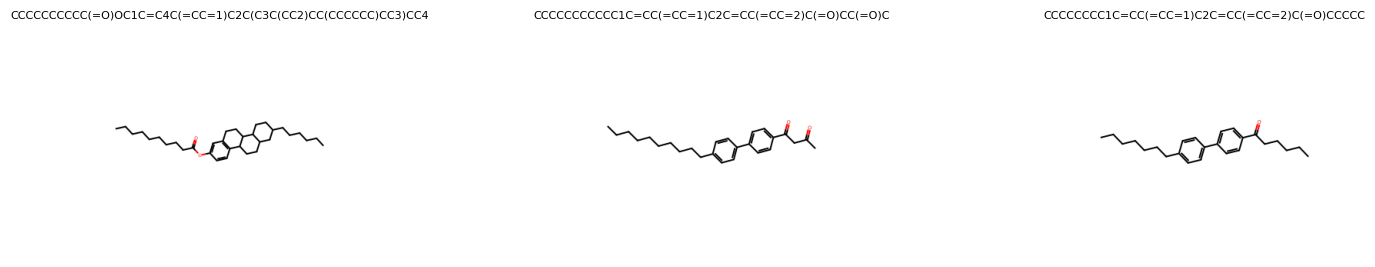

In [9]:
# Edit this list with the SMILES you want to predict.
new_df = pd.DataFrame({
    "SMILES": [
        "CCCCCCCCCC(=O)OC1C=C4C(=CC=1)C2C(C3C(CC2)CC(CCCCCC)CC3)CC4",   # Cr 76.8 A 112.5 N* 119.8 is
        "CCCCCCCCCCC1C=CC(=CC=1)C2C=CC(=CC=2)C(=O)CC(=O)C",             # Cr 86 E 97 B 107 A 135 is
        "CCCCCCCC1C=CC(=CC=1)C2C=CC(=CC=2)C(=O)CCCCC",                  # Cr 94.3 B 95.6 A 103.8 is
    ],
})
print(f"{len(new_df)} molecule(s) will be predicted")

# Preview the first few structures
n = min(4, len(new_df))
fig, axs = plt.subplots(1, n, figsize=(6 * n, 3))
axs = np.atleast_1d(axs)
for j in range(n):
    smi = new_df["SMILES"].iloc[j]
    axs[j].imshow(Draw.MolToImage(Chem.MolFromSmiles(smi)))
    axs[j].axis("off")
    axs[j].set_title(smi, fontsize=8)
plt.show()


### 5.1 CatBoost (gradient boosting on Mordred descriptors)

In [10]:
model_phase_fn       = "CatBoost_phase.cbm"
model_temperature_fn = "CatBoost_temperature_7000epochs.cbm"

varnames = pd.read_csv("varnames.csv").iloc[:, 1].values.tolist()

model_phase = CatBoostClassifier()
model_phase.load_model(model_phase_fn)
model_temperature = CatBoostRegressor()
model_temperature.load_model(model_temperature_fn)

print(f"Loaded {model_phase_fn!r} and {model_temperature_fn!r}")
print(f"{len(varnames)} Mordred descriptors expected")


Loaded 'CatBoost_phase.cbm' and 'CatBoost_temperature_7000epochs.cbm'
1613 Mordred descriptors expected


In [11]:
# Compute Mordred descriptors for the input SMILES
calc = Calculator(descriptors, ignore_3D=True)
mols = [Chem.MolFromSmiles(s) for s in new_df["SMILES"]]
mds  = calc.pandas(mols, nproc=num_cores, ipynb=True)
mds["ID"] = new_df.index
mds = mds.set_index("ID")

pred_df = pd.concat([new_df, mds], axis=1)
X_test  = pred_df[varnames]

# Predict
prob_phase       = model_phase.predict_proba(X_test)
pred_temperature = model_temperature.predict(X_test)

# Assemble a tidy result dataframe
res = pd.concat([
    pd.DataFrame(prob_phase > 0.5, columns=[f"pred_{t}type"  for t in phase_types_chiral]),
    pd.DataFrame(prob_phase,        columns=[f"prob_{t}type"  for t in phase_types_chiral]),
    pd.DataFrame(pred_temperature,  columns=[f"pred_{t}"      for t in temperature_types]),
], axis=1)
res["ID"] = new_df.index
res = res.set_index("ID")
res = pd.concat([new_df, res], axis=1)
res.insert(1, "pred_phases", pred_phases(res))
res


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

,SMILES,pred_phases,pred_Ntype,pred_Atype,pred_Btype,pred_Ctype,pred_Etype,pred_Ftype,pred_Gtype,pred_Htype,pred_Itype,pred_Jtype,pred_Dhtype,pred_BPtype,pred_N*type,pred_C*type,pred_E*type,pred_F*type,pred_I*type,prob_Ntype,prob_Atype,prob_Btype,prob_Ctype,prob_Etype,prob_Ftype,prob_Gtype,prob_Htype,prob_Itype,prob_Jtype,prob_Dhtype,prob_BPtype,prob_N*type,prob_C*type,prob_E*type,prob_F*type,prob_I*type,pred_Clearing,pred_Melting,pred_Np,pred_Nm,pred_Ap,pred_Am,pred_Bp,pred_Bm,pred_Cp,pred_Cm,pred_Ep,pred_Em,pred_Fp,pred_Fm,pred_Gp,pred_Gm,pred_Hp,pred_Hm,pred_Ip,pred_Im,pred_Jp,pred_Jm,pred_Dhp,pred_Dhm,pred_BPp,pred_BPm
0,CCCCCCCCCC(=O)OC1C=C4C(=CC=1)C2C(C3C(CC2)CC(CC...,Cr 75.46 78.63 A 112.96 98.96 N* 115.85 114.69 is,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,0.002336,0.988536,0.000176,0.000001,0.000047,7.589477e-08,1.276424e-07,4.289076e-09,4.176834e-09,9.604323e-09,1.657067e-09,5.167354e-08,9.963195e-01,2.447170e-07,2.243535e-09,1.821271e-08,1.909608e-08,114.685048,75.460343,115.846028,98.957943,112.956286,78.625270,122.530411,66.142333,78.550239,78.753351,107.701538,85.938576,108.005461,90.478279,87.600146,68.432781,113.361406,85.513196,108.355508,86.010517,113.506148,70.485943,121.557215,83.748619,136.230438,135.057381
1,CCCCCCCCCCC1C=CC(=CC=1)C2C=CC(=CC=2)C(=O)CC(=O)C,Cr 86.10 85.94 E 97.01 96.69 B 106.96 102.70 A...,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0.000066,0.990990,0.992041,0.000012,0.999051,6.062833e-08,3.471046e-08,6.406385e-09,3.243953e-10,3.713601e-09,1.307500e-08,6.174654e-10,1.354484e-09,1.756517e-08,6.592606e-09,9.587908e-10,5.468114e-10,116.324434,86.103965,90.241544,88.837827,129.973976,102.704459,106.964494,96.693572,97.952837,97.117939,97.006510,85.941823,92.643296,70.709963,86.705719,68.177243,76.621635,56.423097,82.784001,65.876367,66.795940,67.464404,134.353848,89.344677,115.121740,114.974312
2,CCCCCCCC1C=CC(=CC=1)C2C=CC(=CC=2)C(=O)CCCCC,Cr 86.23 92.80 B 94.04 91.75 A 102.41 106.19 is,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.000009,0.998218,0.995238,0.000107,0.000233,7.837772e-07,1.286303e-08,4.749492e-08,1.080837e-07,2.337103e-08,7.113838e-11,1.887847e-10,1.520011e-14,2.015049e-11,1.053088e-09,2.128538e-10,1.882557e-09,106.193416,86.233414,80.776170,81.236132,102.411799,91.753466,94.043794,92.798121,75.990179,76.041029,88.166934,64.099606,85.853326,69.599405,64.191689,47.004937,63.316607,45.271365,64.993277,49.024684,73.339257,69.513367,117.090735,79.987283,115.086619,113.827344


### 5.2 GNN (graph-based prediction)

In [12]:
# Default to the modern state_dict checkpoint; fall back to the legacy
# full-pickle ``.pth`` for backward compatibility.
import os as _os
_candidates = ["GATv2Conv_phase_temp_cv0.pt",
               "GATv2Conv_phase_temp_cv0.pth"]
model_GNN_fn = next((p for p in _candidates if _os.path.isfile(p)), _candidates[0])
print(f"Loading GNN checkpoint: {model_GNN_fn}")

model = load_gnn(model_GNN_fn, map_location=device).to(device)
model.eval()
model


Loading GNN checkpoint: GATv2Conv_phase_temp_cv0.pt


GNN(
  (convs): ModuleList(
    (0): GATv2Conv(44, 64, heads=4)
    (1-11): 11 x GATv2Conv(256, 64, heads=4)
  )
  (bns): ModuleList(
    (0-11): 12 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): ModuleList(
    (0-2): 3 x Linear(in_features=512, out_features=512, bias=True)
  )
  (fc2): ModuleList(
    (0): Linear(in_features=512, out_features=34, bias=True)
    (1-2): 2 x Linear(in_features=512, out_features=26, bias=True)
  )
)

In [13]:
# Build a PyG dataset — dummy target columns are only needed for shape compatibility
pred_df = new_df.copy()
pred_df[phase_targets] = np.zeros((len(pred_df), len(phase_targets)))
pred_df[temp_targets]  = np.zeros((len(pred_df), len(temp_targets)))

new_dataset = LCDataset(
    pred_df["SMILES"],
    y_long=pred_df[phase_targets],
    y_float=pred_df[temp_targets],
    device=device, explicitH=explicitH,
    atom_encoding=atom_encoding, exclude=exclude_attr,
)
predict_loader = DataLoader(new_dataset, batch_size=128)

res = predict(predict_loader, mode="both",
              targets=phase_targets + temp_targets,
              output_channel_masks=new_dataset.output_channel_masks)
res = pd.DataFrame(res).drop(columns=[k for k in res if k.startswith(("true_", "error_"))])
res["ID"] = new_df.index
res = res.set_index("ID")
res = pd.concat([new_df, res], axis=1)
res.insert(2, "pred_Phases", pred_phases(res))
res


#node features 44,  #edge features 10


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

,SMILES,pred_Ntype,pred_Phases,conf_Ntype,pos_conf_Ntype,pred_Atype,conf_Atype,pos_conf_Atype,pred_Btype,conf_Btype,pos_conf_Btype,pred_Ctype,conf_Ctype,pos_conf_Ctype,pred_Etype,conf_Etype,pos_conf_Etype,pred_Ftype,conf_Ftype,pos_conf_Ftype,pred_Gtype,conf_Gtype,pos_conf_Gtype,pred_Htype,conf_Htype,pos_conf_Htype,pred_Itype,conf_Itype,pos_conf_Itype,pred_Jtype,conf_Jtype,pos_conf_Jtype,pred_Dhtype,conf_Dhtype,pos_conf_Dhtype,pred_BPtype,conf_BPtype,pos_conf_BPtype,pred_N*type,conf_N*type,pos_conf_N*type,pred_C*type,conf_C*type,pos_conf_C*type,pred_E*type,conf_E*type,pos_conf_E*type,pred_F*type,conf_F*type,pos_conf_F*type,pred_I*type,conf_I*type,pos_conf_I*type,pred_Clearing,pred_Melting,pred_Np,pred_Nm,pred_Ap,pred_Am,pred_Bp,pred_Bm,pred_Cp,pred_Cm,pred_Ep,pred_Em,pred_Fp,pred_Fm,pred_Gp,pred_Gm,pred_Hp,pred_Hm,pred_Ip,pred_Im,pred_Jp,pred_Jm,pred_Dhp,pred_Dhm,pred_BPp,pred_BPm
0,CCCCCCCCCC(=O)OC1C=C4C(=CC=1)C2C(C3C(CC2)CC(CC...,0,Cr 79.96 108.30 is,0.530485,0.469514,0,0.500230,0.499770,0,0.999140,0.000860,0,0.999806,0.000194,0,0.956821,0.043179,0,1.000000,2.494609e-07,0,0.999945,0.000055,0,0.999960,0.000040,0,0.999853,1.467436e-04,0,0.999990,0.000010,0,0.972135,0.027865,0,0.999906,9.387892e-05,0,0.701162,2.988380e-01,0,0.995512,4.488461e-03,0,0.999752,0.000248,0,0.999959,4.095526e-05,0,0.999967,3.353300e-05,108.298088,79.962563,109.477173,88.955704,99.204536,77.890930,91.425125,74.277901,89.693367,80.345810,85.358681,78.687302,84.552284,70.266922,91.125008,80.128342,114.790146,70.232529,76.578300,77.139412,85.905426,66.242485,107.815720,71.582825,109.506248,109.431160
1,CCCCCCCCCCC1C=CC(=CC=1)C2C=CC(=CC=2)C(=O)CC(=O)C,0,Cr 98.35 92.18 E 108.23 102.21 A 137.92 137.63 is,0.996048,0.003952,1,0.978398,0.978398,0,0.699639,0.300361,0,0.998591,0.001409,1,0.729558,0.729558,0,0.999806,1.939106e-04,0,0.999904,0.000096,0,0.999905,0.000095,0,0.999999,6.290475e-07,0,0.999988,0.000012,0,0.999923,0.000077,0,1.000000,1.888163e-08,0,0.999999,9.303563e-07,0,1.000000,8.845222e-09,0,0.999972,0.000028,0,1.000000,1.317815e-07,0,1.000000,4.411954e-07,137.634079,98.346199,135.245697,147.393448,137.920914,102.211578,111.551666,97.621796,116.374619,97.724388,108.231125,92.183319,104.416275,93.818474,106.057144,94.888336,101.885254,76.571709,101.235428,85.031105,86.087807,88.140137,134.192841,100.757423,128.892776,129.941910
2,CCCCCCCC1C=CC(=CC=1)C2C=CC(=CC=2)C(=O)CCCCC,0,Cr 89.73 88.18 B 98.21 91.78 A 98.93 98.63 is,0.998878,0.001122,1,0.738567,0.738567,1,0.844493,0.844493,0,0.998920,0.001080,0,0.907524,0.092476,0,0.999952,4.778188e-05,0,0.999933,0.000067,0,0.999862,0.000138,0,0.999982,1.821870e-05,0,0.999985,0.000015,0,0.999617,0.000384,0,1.000000,3.352852e-09,0,0.999999,9.719590e-07,0,1.000000,9.705131e-09,0,0.999990,0.000010,0,0.999998,1.496254e-06,0,0.999942,5.765077e-05,98.632851,89.734344,98.971802,92.716782,98.928253,91.778786,98.208290,88.177238,100.203529,85.758049,85.061066,81.689537,96.915390,88.202179,93.844475,82.597275,89.194496,76.506096,91.051445,81.928490,80.415016,88.735565,103.989853,86.777351,98.091507,98.467476


## 6. Training models on your own data

This section expects a *descriptor database* — a Parquet (or CSV) file
produced by [Section 7](#7.-Preparing-a-dataset-from-SMILES) that contains
the parsed phase columns together with all Mordred descriptors.


### 6.1 Load dataset

In [ ]:
# Path to the descriptor database produced by Section 7.
# Either a parquet (fast) or csv (portable) file is accepted.
descriptor_fn = os.path.expanduser("LiqCryst52.parquet")
# descriptor_fn = "sample_desc.csv"       # tiny dataset, good for smoke-testing

n_splits                = 5      # number of CV folds
remove_duplicate_SMILES = True
min_number_of_NandC     = 12     # drop molecules with fewer N+C atoms

if not os.path.isfile(descriptor_fn):
    raise FileNotFoundError(descriptor_fn)

if descriptor_fn.endswith(".parquet"):
    print("Loading parquet ...")
    df = pd.read_parquet(descriptor_fn)
    if "ID" in df:
        df = df.sort_values("ID").set_index("ID")
else:
    print("Loading csv ...")
    df = pd.read_csv(descriptor_fn, low_memory=False).sort_values("ID").set_index("ID")

if "num_C" in df:
    df = df.drop(columns=["num_H", "num_N", "num_C"])
# Ensure that 'Phases' stays near the front of the column order
phases_col = df.pop("Phases")
df.insert(2, "Phases", phases_col)

print(f"# entries: {len(df)}")
if remove_duplicate_SMILES:
    vc = df["SMILES"].value_counts()
    df = df[~df["SMILES"].isin(vc[vc > 1].index)]
    print(f"# entries after removing duplicates: {len(df)}")


In [ ]:
# Split asterisk phases (e.g. N*) into separate binary targets
if separate_asterisk_phases:
    asterisk_phases = []
    for lt in phase_types:
        mask = df[lt + "type"] > 1
        if mask.sum() == 0:
            continue
        asterisk_phases.append(lt + "*")
        df[lt + "*type"] = 0
        df.loc[mask, lt + "*type"] = 1
        df.loc[mask, lt + "type"]  = 0
        df.loc[mask, lt + "*p"]    = df.loc[mask, lt + "p"]
        df.loc[mask, lt + "*m"]    = df.loc[mask, lt + "m"]
        df.loc[mask, lt + "p"] = np.nan
        df.loc[mask, lt + "m"] = np.nan
    print("chiral phases:", asterisk_phases)

# Drop very small molecules
if min_number_of_NandC > 0:
    df = df[(df["nC"] + df["nN"]) >= min_number_of_NandC]
    print(f"# after excluding small molecules: {len(df)}")

for flag in ("exclude", "prohibited", "reentrant"):
    if flag in df:
        df[flag] = df[flag].astype(bool)
        df = df[~df[flag]]
        print(f"# after dropping {flag!r}: {len(df)}")

if "Clearingtype" in df:
    df = df[df["Clearingtype"] == 1]
    print(f"# after restricting to standard clearing: {len(df)}")

# Drop rows with physically impossible transitions (Tm > Tp)
for lt in phase_types:
    mask = df[lt + "m"] > df[lt + "p"]
    if mask.sum() > 0:
        print(f"  non-increasing phase transition in {lt}: {mask.sum()} / {(df[lt+'type']>0).sum()}")
    df = df[~mask]

# Sentinel invalid temperatures → NaN
for tt in temperature_types:
    df.loc[(df[tt] < kelv) | (df[tt] >= 800) | (df[tt] == 0), tt] = np.nan

# Skip entries whose raw 'Phases' string contains suspicious tokens
for tok in ("?", " 0 ", "X", "S", "no", "un", "ex"):
    mask = ~df["Phases"].str.contains(tok, regex=False, na=False)
    if (~mask).sum() > 0:
        print(f"  excluding {(~mask).sum()} entries containing {tok!r}")
    df = df[mask]

# Require at least one known transition temperature
df = df[~df[temperature_types].min(axis=1).isna()]
print(f"# after filtering: {len(df)}")
df.head()


### 6.2 CatBoost

#### Phase-existence classification

In [ ]:
sub_df = df
print("prediction targets:", phase_targets)
print(f"number of SMILES : {len(sub_df)}")

# Cross-validation splits
train_indices, test_indices = cv_split("classification", sub_df,
                                       n_splits=n_splits, targets=phase_targets)


In [ ]:
use_desc  = "All"      # "Shape" / "Electric" / "Flexible" / "ShapeElectric" / ...
varnames  = list(desc_names[use_desc])

X = sub_df[varnames]
Y = sub_df[phase_targets]
print(f"X: {X.shape},  Y: {Y.shape}")

epochs = 5000
lr     = 0.3

models = []
for i, (train_i, test_i) in enumerate(zip(train_indices, test_indices)):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train, y_test = Y.iloc[train_i], Y.iloc[test_i]

    clf = CatBoostClassifier(
        num_boost_round=epochs, verbose=500,
        loss_function="MultiLogloss", eval_metric="Accuracy",
        learning_rate=lr, random_seed=random_state,
        l2_leaf_reg=1, thread_count=num_cores,
    )
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], plot=True)
    models.append(clf)

    pr = clf.predict_proba(X_test)
    for j, target in enumerate(phase_targets):
        acc = ((pr[:, j] > 0.5) == y_test.iloc[:, j]).mean()
        print(f"  CV{i} {target}: acc {acc:.4f}")


In [ ]:
# Persist the final fold as the shipping model
clf.save_model("CatBoost_phase.cbm", format="cbm")
pd.DataFrame(varnames).to_csv("varnames.csv")
print("Saved CatBoost_phase.cbm and varnames.csv")


In [ ]:
# Save out-of-fold predictions
result_df = sub_df[["SMILES"] + phase_targets].copy()
pred = np.zeros(Y.shape)
for i, (train_i, test_i) in enumerate(zip(train_indices, test_indices)):
    pred[test_i] = models[i].predict_proba(X.iloc[test_i])
for j, target in enumerate(phase_targets):
    result_df["pred_" + target] = pred[:, j]
    acc = ((pred[:, j] > 0.5) == sub_df[target]).mean()
    print(f"{target}: acc {acc:.4f}")
result_df = result_df.sort_values("ID")
result_df.to_csv(os.path.join(outdir, f"result_Cat_{use_desc}_phase.csv"), index=False)
result_df.head()


#### Transition-temperature regression

In [ ]:
use_desc = "All"
varnames = list(desc_names[use_desc])

X = sub_df[varnames]
Y = sub_df[temperature_types]
pred = np.zeros_like(Y)

epochs = 10000
lr     = 0.3

models = []
for i, (train_i, test_i) in enumerate(zip(train_indices, test_indices)):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train, y_test = Y.iloc[train_i], Y.iloc[test_i]

    reg = CatBoostRegressor(
        num_boost_round=epochs, verbose=500,
        loss_function="MultiRMSEWithMissingValues",
        learning_rate=lr, random_seed=random_state,
        l2_leaf_reg=1, thread_count=num_cores,
    )
    reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], plot=True)
    pred[test_i] = reg.predict(X_test)
    models.append(reg)
    print(np.abs(y_test - pred[test_i]).mean(axis=0))

reg.save_model("CatBoost_temperature.cbm", format="cbm")
print("Saved CatBoost_temperature.cbm")


In [ ]:
# Save OOF predictions for temperature
result_df = sub_df[["SMILES"] + temperature_types].copy()
for j, target in enumerate(temperature_types):
    result_df["pred_"  + target] = pred[:, j]
    result_df["error_" + target] = np.abs(pred[:, j] - Y.iloc[:, j].values)
    mae = result_df["error_" + target].mean()
    print(f"{target}: MAE {mae:.3f}")
result_df = result_df.sort_values("ID")
result_df.to_csv(os.path.join(outdir, f"result_Cat_{use_desc}_temperature.csv"), index=False)
result_df.head()


In [ ]:
# Top-100 feature importance for the last-fold regressor
num = 100
sorted_idx = reg.feature_importances_.argsort()[-num:]
plt.figure(figsize=(6, 18))
plt.barh(np.array(varnames)[sorted_idx],
         reg.feature_importances_[sorted_idx], color="turquoise")
plt.xlabel("CatBoost feature importance")
plt.tight_layout()
plt.show()


In [ ]:
# SHAP values (optional; requires `pip install shap`)
try:
    import shap
    explainer = shap.TreeExplainer(reg)
    shap_values = explainer.shap_values(X.iloc[test_indices[-1]])
    shap.summary_plot(shap_values, X.iloc[test_indices[-1]],
                      feature_names=np.array(varnames))
except ImportError:
    print("SHAP not installed — run `pip install shap` to enable this cell.")


### 6.3 LightGBM

In [ ]:
import lightgbm as lgb
from lightgbm.callback import CallbackEnv

print(f"LightGBM: {lgb.__version__}")


def accuracy_gbm(preds, data):
    y_true = data.get_label()
    if preds.ndim == 1:
        preds = preds.reshape(-1, len(y_true)).T
    return "accuracy", (y_true == np.argmax(preds, axis=1)).mean(), True


def MAE(preds, data):
    y_true = data.get_label()
    return "MAE", np.nanmean(np.abs(y_true - preds)), False


class LgbmProgressBarCallback:
    """tqdm progress bar for LightGBM training."""
    def __init__(self, description: str = "LGBM", update_interval: int = 10):
        self.description = description
        self.update_interval = update_interval
        self.pbar = tqdm()

    def __call__(self, env: CallbackEnv):
        if env.iteration == env.begin_iteration:
            self.pbar.reset(total=env.end_iteration - env.begin_iteration)
            self.pbar.set_description(self.description, refresh=False)
        if (env.iteration - env.begin_iteration) % self.update_interval == 0:
            if env.evaluation_result_list:
                self.pbar.set_postfix(OrderedDict(
                    (f"{e[0]}:{e[1]}", f"{e[2]:.5f}") for e in env.evaluation_result_list
                ), refresh=False)
        self.pbar.update(1)
        self.pbar.refresh()


def GBM_importance(models, varnames):
    importance = pd.concat(
        [pd.DataFrame(m.feature_importance(), index=varnames, columns=["importance"]) for m in models],
        axis=1, keys=[f"CV{i}" for i in range(len(models))],
    )
    importance["median"] = importance.median(axis=1)
    # Tag each feature with the descriptor family it belongs to
    importance["dtype"] = [
        next((dt for dt, dns in desc_names.items() if k in dns and dt in ("Shape", "Electric", "Flexible")), "Other")
        for k in importance.index
    ]
    return importance


#### Phase-existence classification

In [ ]:
targets = [lt + "type" for lt in phase_types]
sub_df  = df
print("prediction targets:", targets)
print(f"number of SMILES : {len(sub_df)}")

use_desc = "All"
varnames = list(desc_names[use_desc])
X = sub_df[varnames].values
epochs = 10000

params = {
    "learning_rate": 0.01, "boosting_type": "gbdt",
    "objective": "multiclassova", "is_unbalance": True,
    "max_depth": 10, "num_leaves": 256,
    "seed": random_state, "force_col_wise": True, "min_child_samples": 20,
    "lambda_l2": 0.327,
    "feature_fraction": 0.775, "bagging_fraction": 0.643,
    "num_threads": num_cores, "device_type": "cpu", "verbosity": -1,
}

evals_result = {t: [{} for _ in range(n_splits)] for t in targets}
models       = {t: [] for t in targets}
result_df    = sub_df[["SMILES", "Phases"]].copy()

for tid, target in enumerate(targets):
    Y = sub_df[target].values
    num_class = max(len(np.unique(Y)), 2)
    print(f"[{tid+1}/{len(targets)}] {target}: class counts = {dict(Counter(Y))}")
    pred = np.zeros((len(Y), num_class))

    iter_params = dict(params, num_class=num_class)
    for i, (train_i, test_i) in enumerate(zip(train_indices, test_indices)):
        X_train, X_test = X[train_i], X[test_i]
        y_train, y_test = Y[train_i], Y[test_i]
        d_train = lgb.Dataset(X_train, label=y_train)
        d_test  = lgb.Dataset(X_test,  label=y_test, params={"verbose": -1})

        clf = lgb.train(iter_params, d_train, num_boost_round=epochs,
                        valid_names=["eval"], valid_sets=[d_test], feval=accuracy_gbm,
                        callbacks=[LgbmProgressBarCallback(),
                                   lgb.callback.record_evaluation(evals_result[target][i])])
        pred[test_i] = clf.predict(X_test)
        models[target].append(clf)

    importance = GBM_importance(models[target], varnames).sort_values("median", ascending=False)
    importance.to_csv(os.path.join(outdir, f"importance_LGBM_{use_desc}_{target}.csv"))

    result_df["true_"     + target] = Y
    result_df["pred_"     + target] = np.argmax(pred, axis=1)
    result_df["conf_"     + target] = np.max(pred, axis=1)
    result_df["pos_conf_" + target] = pred[:, 1:].sum(axis=1)

result_df.to_csv(os.path.join(outdir, f"result_LGBM_{use_desc}_phase.csv"))
result_df.head()


In [ ]:
# Persist the first-fold model for each target
for tg, mdls in models.items():
    mdls[0].save_model(f"LGBM_model_{tg}.txt", num_iteration=epochs)

summary = print_results(result_df, targets, display="less")
summary.to_csv(os.path.join(outdir, f"summary_LGBM_{use_desc}_phase.csv"))
summary


In [ ]:
# Training curves
fig, axs = plt.subplots(len(targets), 2, figsize=(8, 4 * len(targets)))
axs = axs.reshape((len(targets), 2))
for tid, target in enumerate(targets):
    for i in range(len(evals_result[target])):
        for _, dic in evals_result[target][i].items():
            for j, (k, v) in enumerate(dic.items()):
                axs[tid, j].plot(v)
    axs[tid, 0].set_title(f"loss_{target}")
    axs[tid, 1].set_title(f"accuracy_{target}")
plt.tight_layout()
plt.show()


#### Transition-temperature regression

In [ ]:
use_desc = "All"
epochs   = 50000
varnames = list(desc_names[use_desc])

params = {
    "learning_rate": 0.01, "boosting_type": "gbdt",
    "objective": "regression", "metric": "l2",
    "seed": random_state, "force_col_wise": True,
    "min_data": 20, "max_depth": 10, "num_leaves": 2 ** 5,
    "lambda_l2": 0.327,
    "num_threads": num_cores, "device_type": "cpu", "verbosity": -1,
    "feature_fraction": 0.494, "bagging_fraction": 0.845, "bagging_freq": 3,
}

X = df[varnames].values
evals_result = {t: [{} for _ in range(n_splits)] for t in temperature_types}
models       = {t: [] for t in temperature_types}
result_df    = df[["SMILES", "Phases"]].copy()

for tid, target in enumerate(temperature_types):
    Y = sub_df[target].values
    print(f"[{tid+1}/{len(temperature_types)}] {target}")
    pred = np.zeros_like(Y)

    for i, (train_i, test_i) in enumerate(zip(train_indices, test_indices)):
        X_train, X_test = X[train_i], X[test_i]
        y_train, y_test = Y[train_i], Y[test_i]
        train_mask, test_mask = ~np.isnan(y_train), ~np.isnan(y_test)
        d_train = lgb.Dataset(X_train[train_mask], label=y_train[train_mask], params={"verbose": -1})
        d_test  = lgb.Dataset(X_test[test_mask],  label=y_test[test_mask],  params={"verbose": -1})

        clf = lgb.train(params, d_train, num_boost_round=epochs,
                        valid_names=["eval"], valid_sets=[d_test], feval=MAE,
                        callbacks=[LgbmProgressBarCallback(),
                                   lgb.callback.record_evaluation(evals_result[target][i])])
        pred[test_i] = clf.predict(X_test)
        models[target].append(clf)

    importance = GBM_importance(models[target], varnames).sort_values("median", ascending=False)
    importance.to_csv(os.path.join(outdir, f"importance_LGBM_{use_desc}_{target}.csv"))

    result_df["true_"  + target] = Y
    result_df["pred_"  + target] = pred
    result_df["error_" + target] = np.abs(pred - Y)
    result_df.to_csv(os.path.join(outdir, f"result_LGBM_{use_desc}_temperature.csv"))

result_df[[f"error_{t}" for t in temperature_types]].describe()


### 6.4 Graph Neural Network

In [ ]:
# Build the PyG dataset once — it is reused across experiments
sub_df = df
print(f"number of SMILES: {len(sub_df)}")

train_indices, test_indices = cv_split("classification", sub_df,
                                       n_splits=n_splits, targets=phase_targets)

dataset = LCDataset(
    sub_df["SMILES"],
    y_long=sub_df[phase_targets], y_float=sub_df[temp_targets],
    device=device, explicitH=explicitH,
    atom_encoding=atom_encoding, exclude=exclude_attr,
)

print(f"#classification output {dataset.output_channels[0]},  "
      f"#regression output {dataset.output_channels[1]}")
print("num classes per phase:", [sum(m) for m in dataset.output_channel_masks])


#### Joint phase + temperature learning

In [ ]:
# --- Optimisation configuration -------------------------------------
conv_type      = "GATv2Conv"      # or "NNConv"
hidden_channel = 256
num_heads      = 4
num_layers     = 12
dropout        = 0.5
batchsize      = 128
lr             = 1e-3
epochs         = 300
warmup_epochs  = 10
plot_interval  = 100

id_emb_dim = 5 if atom_encoding == "integer" else 0

train_loss_hist, test_loss_hist = [], []
train_MAE_hist,  test_MAE_hist  = [], []
train_acc_hist,  test_acc_hist  = [], []
train_f1_hist,   test_f1_hist   = [], []
results = []

for cv in range(n_splits):
    print(f"CV {cv}  [{datetime.now().strftime('%H:%M:%S')}]")
    train_loss_hist.append([])
    test_loss_hist.append([])
    train_MAE_hist.append({k: [] for k in temp_targets})
    test_MAE_hist.append({k:  [] for k in temp_targets})
    train_acc_hist.append({k: [] for k in phase_targets})
    test_acc_hist.append({k:  [] for k in phase_targets})
    train_f1_hist.append({k:  [] for k in phase_targets})
    test_f1_hist.append({k:   [] for k in phase_targets})

    model = GNN(
        hidden_channels=hidden_channel, num_layers=num_layers,
        dim_node_attr=dataset.dim_node_attr + id_emb_dim,
        dim_edge_attr=dataset.dim_edge_attr,
        out_channels=dataset.output_channels + [len(temp_targets)],
        id_emb_dim=id_emb_dim, num_heads=num_heads, conv_type=conv_type,
        dropout=dropout,
    ).to(device)
    optimizer = torch.optim.NAdam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs),
            torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[epochs // 3, 2 * epochs // 3], gamma=0.1),
        ],
        milestones=[warmup_epochs],
    )

    train_loader = DataLoader(dataset[train_indices[cv]], batch_size=batchsize, shuffle=True)
    test_loader  = DataLoader(dataset[test_indices[cv]],  batch_size=batchsize)
    t0 = time.time()

    with tqdm(range(epochs), unit="epoch") as titer:
        for epoch in titer:
            titer.set_description(f"Epoch {epoch}")
            tr_loss, tr_acc, tr_f1, tr_MAEs = train(train_loader, mode="both",
                                                    output_channel_masks=dataset.output_channel_masks)
            te_loss, te_acc, te_f1, te_MAEs = test(test_loader,  mode="both",
                                                    output_channel_masks=dataset.output_channel_masks)

            if epoch % plot_interval == 0 or epoch == epochs - 1:
                etim = time.time() - t0
                print(f"  e{epoch:4d}  train {tr_loss:.4f} / test {te_loss:.4f}  "
                      f"(train MAE {tr_MAEs[0].avg:.3f}, test MAE {te_MAEs[0].avg:.3f})  "
                      f"[{etim:.0f}s]")

            train_loss_hist[-1].append(tr_loss)
            test_loss_hist[-1].append(te_loss)
            for j, k in enumerate(temp_targets):
                train_MAE_hist[-1][k].append(tr_MAEs[j].avg)
                test_MAE_hist[-1][k].append(te_MAEs[j].avg)
            for j, k in enumerate(phase_targets):
                train_acc_hist[-1][k].append(tr_acc[j].avg)
                test_acc_hist[-1][k].append(te_acc[j].avg)
                train_f1_hist[-1][k].append(tr_f1[j].avg)
                test_f1_hist[-1][k].append(te_f1[j].avg)
            titer.set_postfix(train_loss=tr_loss, test_loss=te_loss)

    # Out-of-fold predictions
    res = predict(test_loader, mode="both",
                  targets=phase_targets + temp_targets,
                  output_channel_masks=dataset.output_channel_masks)
    res = pd.DataFrame(res)
    res["index"] = test_indices[cv]
    results.append(res)
    # Save in the portable state_dict format (see load_gnn/save_gnn).
    # save_gnn(model, os.path.join(outdir, f"{conv_type}_phase_temp_cv{cv}.pt"),
    #          extra={"conv_type": conv_type, "cv": cv})

# Assemble results
results_df = sub_df[["SMILES", "Phases"]].copy().reset_index().rename(columns={"index": "ID"})
results_df = pd.concat([results_df, pd.concat(results).set_index("index").sort_index()], axis=1)
results_df["pred_Phases"] = pred_phases(results_df)
results_df.to_csv(os.path.join(outdir, f"result_{conv_type}_phase_temp.csv"), index=False)


In [ ]:
plot_losses(train_loss_hist, test_loss_hist, train_acc_hist, test_acc_hist, ylim=(80, 110))
plot_losses(train_loss_hist, test_loss_hist, train_f1_hist,  test_f1_hist,  ylim=(0.6, 1.0))
plot_losses(train_loss_hist, test_loss_hist, train_MAE_hist, test_MAE_hist, ylim=(0, 25))

summary_csv = print_results(results_df, phase_targets, display="less")
summary_csv.to_csv(os.path.join(outdir, f"summary_{conv_type}_phase_temp.csv"))
summary_csv


In [ ]:
# Temperature error statistics
results_df[[f"error_{k}" for k in temp_targets]].describe()


#### (Optional) Combining GBM and GNN results

In [ ]:
# Concatenate phase predictions from one model with temperature predictions from another
model_type = "LGBM_All"     # "GNN"
phase_df       = pd.read_csv(os.path.join(outdir, f"result_{model_type}_phase.csv"),       index_col="ID").sort_index()
temperature_df = pd.read_csv(os.path.join(outdir, f"result_{model_type}_temperature.csv"), index_col="ID").sort_index()
temperature_df = temperature_df.drop(columns=["Phases", "SMILES"])

results_df = pd.concat([phase_df, temperature_df], axis=1).reset_index().rename(columns={"index": "ID"})
results_df.insert(3, "pred_Phases", pred_phases(results_df))
results_df.to_csv(os.path.join(outdir, f"result_{model_type}_combined.csv"), index=False)
results_df.head()


## 7. Preparing a dataset from SMILES

Use this section to produce the descriptor database consumed by
Section 6.  The input is a CSV with the columns:

- `ID` — integer identifier
- `SMILES` — SMILES string
- `Phases` — LiqCryst-style phase sequence

A tiny `sample.csv` is bundled for testing.


### 7.1 Parse the `Phases` column

In [ ]:
smiles_fn  = "LiqCryst52.csv"          # input: ID, SMILES, Phases
# smiles_fn = "sample.csv"              # small demo file
csv_fn     = "LiqCryst52_desc.csv"      # output CSV
parquet_fn = "LiqCryst52.parquet"       # output parquet (preferred)

# --- Phase vocabulary -----------------------------------------------
exclude_list   = ["X", "BS", "So", "cub", "Are", "Nre", "Nre*",
                  "I/F*", "Dsq", "Dob", "Bhx",
                  "C~a", "C~g", "CA", "CA*", "Tg",
                  "tr", "Y", "S", "D"]
melting_types  = ["Cr", "Cr'", "Tg"]
clearing_types = ["is", "chg", "dec"]

df = pd.read_csv(smiles_fn, low_memory=False).sort_values("ID").set_index("ID")
print(f"Number of SMILES: {len(df)}")


In [ ]:
# Utility predicates
def is_number(x):
    try:
        float(x)
        return True
    except ValueError:
        return False


def is_valid_temp(x):
    if x == "?" or "<" in x or ">" in x or not is_number(x):
        return False
    x = float(x)
    return x >= kelv and x != 0


def is_valid_phase(x):
    if is_number(x) or "(" in x or "<" in x or ">" in x or "=0" in x:
        return False
    return x


# --- Pre-clean the Phases string ------------------------------------
p1 = re.compile("isSciDex.*")   # Cr missing
p2 = re.compile(r"\s]\s")      # J mistakenly transcribed as ]
df["Phases"] = [p2.sub(" J ", p1.sub("is", ph)) for ph in tqdm(df["Phases"])]

# --- Parse each row into phase-type + T- / T+ arrays ----------------
exclude   = np.zeros(len(df), dtype=bool)
reentrant = np.zeros(len(df), dtype=bool)
phtype = {sym: np.zeros(len(df), dtype=np.int8)
          for sym in phase_types + ["Clearing", "Melting"]}
temp_cols = [s + "m" for s in phase_types] + [s + "p" for s in phase_types] + ["Clearing", "Melting"]
phtemp = {sym: np.full(len(df), np.nan, dtype=np.float32) for sym in temp_cols}
phase_words = []

for i, ph in enumerate(tqdm(df["Phases"])):
    parts = ph.split()
    for j, x in enumerate(parts):
        if x in exclude_list:
            exclude[i] = True
        if is_valid_phase(x) and not exclude[i]:
            phase_words.append(x)

        for sym in phase_types:
            search_temp = False
            if x == sym:
                phtype[sym][i] = 1
                search_temp = True
            elif x == sym + "*":
                phtype[sym][i] = 2
                search_temp = True
            if search_temp:
                # T- (left neighbour)
                if j > 0 and is_valid_temp(parts[j - 1]):
                    phtemp[sym + "m"][i] = float(parts[j - 1])
                else:
                    phtemp[sym + "m"][i] = np.nan
                    exclude[i] = True
                # T+ (right neighbour)
                if j < len(parts) - 1 and is_valid_temp(parts[j + 1]):
                    phtemp[sym + "p"][i] = float(parts[j + 1])
                else:
                    phtemp[sym + "p"][i] = np.nan
                    exclude[i] = True

        # Melting / clearing
        if x in melting_types:
            phtype["Melting"][i] = 2 if x == "Tg" else 1
            if j < len(parts) - 1 and is_valid_temp(parts[j + 1]):
                phtemp["Melting"][i] = float(parts[j + 1])
        if x in clearing_types:
            phtype["Clearing"][i] = 1 if x == "is" else 2
            if j > 0 and is_valid_temp(parts[j - 1]):
                phtemp["Clearing"][i] = float(parts[j - 1])

    for uh in phase_types:
        if ph.count(f" {uh} ") + ph.count(f" {uh}* ") > 1:
            reentrant[i] = True

print(f"excluded: {exclude.sum()},  re-entrant: {reentrant.sum()}")
pd.DataFrame(phase_words).value_counts().head(30)


In [ ]:
# Rearrange into one tidy dataframe
df = df.drop(columns=[c for c in ("exclude", "reentrant") if c in df])
df.insert(2, "exclude",   exclude)
df.insert(2, "reentrant", reentrant)

for i, sym in enumerate(phase_types):
    df = df.drop(columns=[c for c in (f"{sym}type", f"{sym}m", f"{sym}p") if c in df])
    df.insert(4 + i, f"{sym}type", phtype[sym])
    df.insert(5 + i, f"{sym}m",    phtemp[f"{sym}m"])
    df.insert(6 + i, f"{sym}p",    phtemp[f"{sym}p"])

for i, sym in enumerate(["Clearing", "Melting"]):
    df = df.drop(columns=[c for c in (f"{sym}type", sym) if c in df])
    df.insert(4 + i, f"{sym}type", phtype[sym])
    df.insert(5 + i, sym,           phtemp[sym])

df.head()


### 7.2 Compute Mordred descriptors

In [ ]:
calc = Calculator(descriptors, ignore_3D=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mds = pd.DataFrame(
        ProgressParallel(n_jobs=num_cores, total=len(df))(
            joblib.delayed(
                lambda x: calc(Chem.MolFromSmiles(x)).fill_missing(np.nan).asdict()
            )(smi) for smi in df["SMILES"]
        )
    )
mds["ID"] = df.index.values
mds = mds.set_index("ID")

df = pd.concat([df, mds], axis=1)

if csv_fn:
    df.reset_index().to_csv(csv_fn, index=False)
    print(f"Wrote {csv_fn}")
if parquet_fn:
    df.to_parquet(parquet_fn, compression="GZIP")
    print(f"Wrote {parquet_fn}")

print("Now rerun Section 6.1 with `descriptor_fn` pointing at this file.")
df.head()


## 8. Appendix

Miscellaneous helpers that are occasionally useful but not required for a
normal run.


### 8.1 LightGBM hyper-parameter tuning (Optuna)

In [ ]:
import optuna

def objective(trial, X, Y, mode="regression"):
    train_x, valid_x, train_y, valid_y = train_test_split(X, Y, test_size=0.25)
    dtrain = lgb.Dataset(train_x, label=train_y)

    param = {
        "objective": "regression", "metric": "l2",
        "verbosity": -1, "boosting_type": "gbdt",
        "num_boost_round": 5000,
        "seed": random_state, "force_col_wise": True,
        "lambda_l1":         trial.suggest_float("lambda_l1",         1e-8, 10.0, log=True),
        "lambda_l2":         trial.suggest_float("lambda_l2",         1e-8, 10.0, log=True),
        "num_leaves":        trial.suggest_int(  "num_leaves",        2, 256),
        "feature_fraction":  trial.suggest_float("feature_fraction",  0.4, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction",  0.4, 1.0),
        "bagging_freq":      trial.suggest_int(  "bagging_freq",      1, 7),
        "min_child_samples": trial.suggest_int(  "min_child_samples", 5, 100),
    }
    if mode == "classification":
        param.update(objective="binary", metric="binary_logloss", is_unbalance=True)

    gbm = lgb.train(param, dtrain)
    preds = gbm.predict(valid_x)
    if mode == "classification":
        return metrics.accuracy_score(valid_y, np.rint(preds))
    return np.mean(np.abs(valid_y - preds))


# Example: tune Np (clearing temperature of N phase)
mode     = "regression"
target   = "Np" if mode == "regression" else "Ntype"
use_desc = "All"
varnames = list(desc_names[use_desc])

np.random.seed(random_state)
sub_df   = df[~df[target].isna()].sample(n=min(20000, (~df[target].isna()).sum()),
                                         random_state=random_state)
X = sub_df[varnames]
Y = sub_df[target] > 0 if mode == "classification" else sub_df[target]

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize" if mode == "classification" else "minimize")
study.optimize(lambda t: objective(t, X, Y, mode=mode), n_trials=100, show_progress_bar=True)

print("Best value :", study.best_trial.value)
print("Best params:", study.best_trial.params)


### 8.2 Descriptor correlation with a phase (Mann–Whitney U test)

In [ ]:
from scipy import stats

# Which descriptors most strongly separate BP-positive from BP-negative molecules?
sub_df  = df
label   = "BPtype"
use_desc = "All"
varnames = list(desc_names[use_desc])

pos = sub_df[label] > 0
print(f"positive: {pos.sum()}, negative: {(~pos).sum()}")

pvals = {}
for d in tqdm(varnames):
    try:
        pvals[d] = stats.mannwhitneyu(sub_df.loc[pos, d], sub_df.loc[~pos, d], nan_policy="omit").pvalue
    except Exception:
        pass
pvals = dict(sorted(pvals.items(), key=lambda x: x[1]))
print("Top-10 most discriminative descriptors:")
for k, v in list(pvals.items())[:10]:
    print(f"  {k:30s} {v:.3e}")


In [ ]:
# Boxplots of the top-5 descriptors with Mann-Whitney annotation
try:
    import seaborn as sns
    from statannotations.Annotator import Annotator

    keys  = list(pvals.keys())[:5]
    pairs = [(0, 1)]
    fig, axs = plt.subplots(1, len(keys), figsize=(18, 8))
    for i, k in enumerate(keys):
        sns.boxplot(data=sub_df, x=label, y=k, ax=axs[i])
        ann = Annotator(axs[i], pairs, data=sub_df, x=label, y=k, verbose=False)
        ann.configure(test="Mann-Whitney", text_format="star", loc="outside",
                      comparisons_correction="Benjamini-Hochberg")
        ann.apply_and_annotate()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("seaborn / statannotations not installed — `pip install seaborn statannotations`.")
